In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
df = pd.read_csv('/Users/palabjinrey/Desktop/BDM project/Webscraping_forProject/Omron_AllReviews.csv')

## Descriptive Statistics

In [3]:
df.head()

,product,title,rating,body,Model number
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nAccurate bp monitor,5,It's accurate and reliable and affordable. Gre...,7143T1
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"4.0 out of 5 stars\nGood, but....",4,Omron is the gold standard for home bp measure...,7143T1
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nPrecision and Convenience ...,5,I recently purchased this Blood Pressure Meter...,7143T1
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,5.0 out of 5 stars\nFullfilled my wish,5,Searched and found this product in Amazon. Goo...,7143T1
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,3.0 out of 5 stars\nLots of features are missing.,3,"No doubt in quality, size cup is short, accura...",7143T1


<Axes: ylabel='count'>

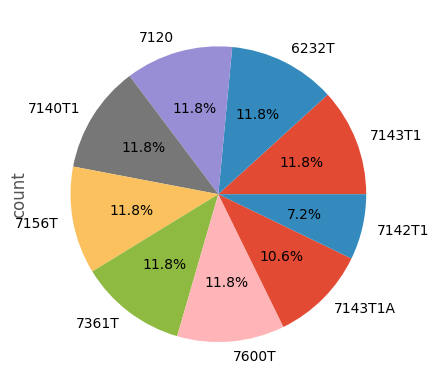

In [4]:
df['Model number'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [5]:
df.shape

(851, 5)

<Axes: title={'center': 'Count of stars'}, xlabel='rating'>

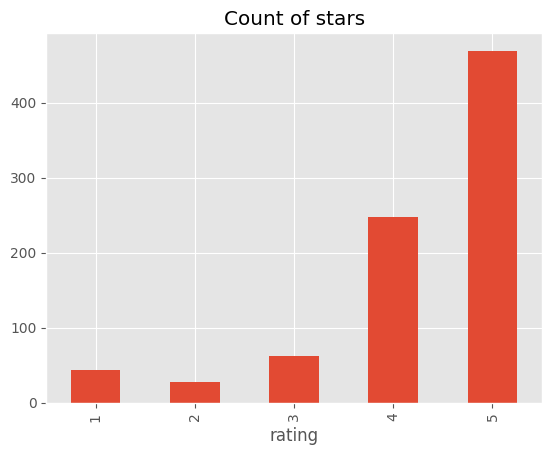

In [6]:
df['rating'].value_counts().sort_index().plot(kind='bar',title='Count of stars')

<Axes: ylabel='count'>

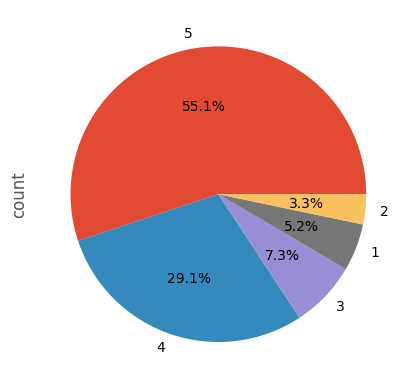

In [7]:
df['rating'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [8]:
df['rating'].value_counts().sort_values()

rating
2     28
1     44
3     62
4    248
5    469
Name: count, dtype: int64

In [9]:
df['body'][88]  # extracting the review at 77th row

'The product is very user friendly and accurate, 5star to the product.However the pricing is very much manupulated, I bought this for 1800 and now during the great Indian festival the price has increased to 2110..... LOL.'

In [10]:
# Extract the part after '\n' in the 'title' column
# If '\n' is found, split the string and take the part after '\n' (index 1), otherwise keep the original text
df['title'] = df['title'].apply(lambda x: x.split('\n', 1)[1] if '\n' in x else x)

In [11]:
df.head()

,product,title,rating,body,Model number
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Accurate bp monitor,5,It's accurate and reliable and affordable. Gre...,7143T1
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"Good, but....",4,Omron is the gold standard for home bp measure...,7143T1
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Precision and Convenience Combined,5,I recently purchased this Blood Pressure Meter...,7143T1
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Fullfilled my wish,5,Searched and found this product in Amazon. Goo...,7143T1
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Lots of features are missing.,3,"No doubt in quality, size cup is short, accura...",7143T1


In [12]:
df['body'].isna().sum()

3

In [13]:
# Remove rows where 'body' is NaN or an empty string
df = df.dropna(subset=['body'])  # Remove rows with NaN in 'body'
df = df[df['body'].str.strip() != '']  # Remove rows with empty or whitespace-only strings

In [14]:
df['body'].isna().sum()

0

In [15]:
df.isna().sum()

product         0
title           0
rating          0
body            0
Model number    0
dtype: int64

In [16]:
df.shape

(848, 5)

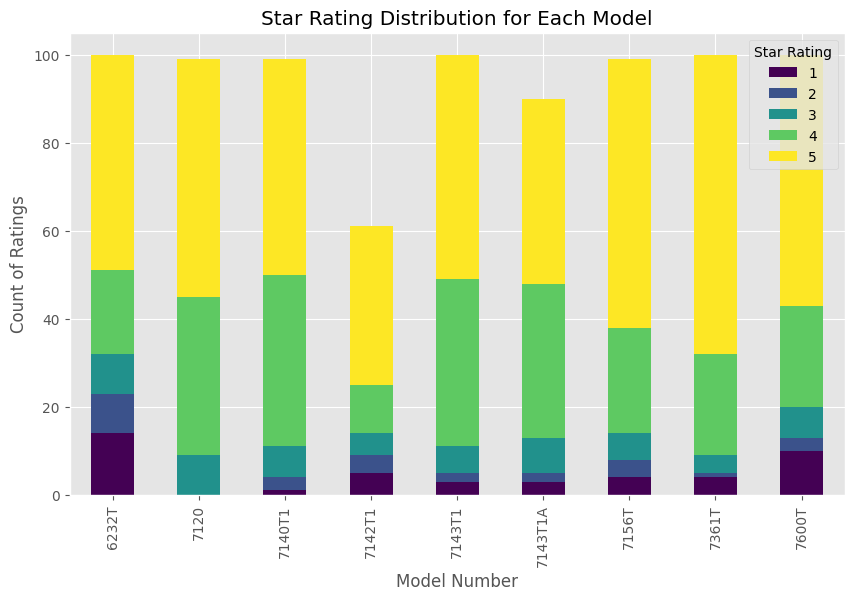

In [17]:
# Calculate the count of each star rating per model
rating_counts = df.groupby(['Model number', 'rating']).size().unstack(fill_value=0)

# Option 1: Stacked Bar Chart
rating_counts.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Star Rating Distribution for Each Model')
plt.xlabel('Model Number')
plt.ylabel('Count of Ratings')
plt.legend(title='Star Rating')
plt.show()


## Creating wordcloud

In [18]:
from PIL import Image
from wordcloud import WordCloud

In [19]:
review_body= " ".join(review for review in df['body'].dropna())
review_body

'It\'s accurate and reliable and affordable. Great product. Omron is the gold standard for home bp measurement. Good instrument, but has a few drawbacks. Its diastolic reading is always higher by about 7-10 points and systolic varies widely even when measured multiple times within a few mins. Yes, bp does vary but not as much as this instrument appears to show! The cuff is another thing that needs improvement, it unrolls if not absolutely fixed very carefully.  IOW, needs lot of care & attention when using this instrument. I\'d say its good, but there are better ones available. I recently purchased this Blood Pressure Meter for my mom, and it has quickly become an essential part of our healthcare routine. The meter provides accurate readings of blood pressure levels, ensuring peace of mind and reliability.What sets this meter apart is its user-friendly design. It can be operated through batteries or a DC charger, making it convenient for everyday use. The indicator for correct cuff wra

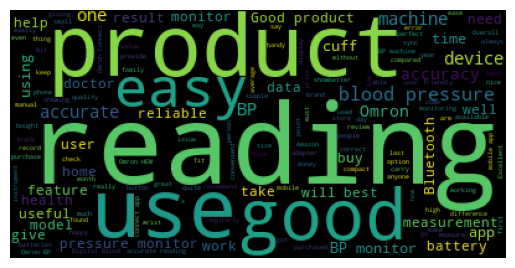

In [20]:
wc = WordCloud().generate(review_body)
plt.axis('off')
plt.imshow(wc)

## Picking a random review and preprocessing it

In [21]:
example = df['body'][89]
example

"I have bought this bp monitor 4 months before still now it works fine. The adaptor mode usage is very useful, Even it doesn't consume much power in battery mode as well. Nice product 👍"

In [22]:
token = nltk.word_tokenize(example)
token

['I',
 'have',
 'bought',
 'this',
 'bp',
 'monitor',
 '4',
 'months',
 'before',
 'still',
 'now',
 'it',
 'works',
 'fine',
 '.',
 'The',
 'adaptor',
 'mode',
 'usage',
 'is',
 'very',
 'useful',
 ',',
 'Even',
 'it',
 'does',
 "n't",
 'consume',
 'much',
 'power',
 'in',
 'battery',
 'mode',
 'as',
 'well',
 '.',
 'Nice',
 'product',
 '👍']

In [23]:
# find part of speech of every word

tagged = nltk.pos_tag(token)

In [24]:
#grouping in chunks
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  I/PRP
  have/VBP
  bought/VBN
  this/DT
  bp/NN
  monitor/NN
  4/CD
  months/NNS
  before/IN
  still/RB
  now/RB
  it/PRP
  works/VBZ
  fine/JJ
  ./.
  The/DT
  adaptor/NN
  mode/NN
  usage/NN
  is/VBZ
  very/RB
  useful/JJ
  ,/,
  Even/RB
  it/PRP
  does/VBZ
  n't/RB
  consume/VB
  much/JJ
  power/NN
  in/IN
  battery/NN
  mode/NN
  as/IN
  well/RB
  ./.
  Nice/NNP
  product/NN
  👍/NN)


## VADER MODEL

Preprocessing only involved tokenisation (for example only, did not tokenise the complete dataset). Will try implementing other preprocessing steps in the next attempt to see if the accuracy improves.

In [25]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm   # tqdm is for progress bar

In [26]:
example

"I have bought this bp monitor 4 months before still now it works fine. The adaptor mode usage is very useful, Even it doesn't consume much power in battery mode as well. Nice product 👍"

In [27]:
sia = SentimentIntensityAnalyzer()
sia.polarity_scores(example)

{'neg': 0.0, 'neu': 0.739, 'pos': 0.261, 'compound': 0.8357}

In [28]:
# Running polarity score on entire dataset

res = {}
for i,row in tqdm(df.iterrows(), total=len(df)):
    text = row['body']
    myid = i
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/848 [00:00<?, ?it/s]

In [29]:
res

{0: {'neg': 0.0, 'neu': 0.631, 'pos': 0.369, 'compound': 0.6249},
 1: {'neg': 0.0, 'neu': 0.766, 'pos': 0.234, 'compound': 0.9761},
 2: {'neg': 0.056, 'neu': 0.771, 'pos': 0.173, 'compound': 0.9489},
 3: {'neg': 0.0, 'neu': 0.65, 'pos': 0.35, 'compound': 0.7184},
 4: {'neg': 0.189, 'neu': 0.654, 'pos': 0.157, 'compound': -0.128},
 5: {'neg': 0.0, 'neu': 0.4, 'pos': 0.6, 'compound': 0.8883},
 6: {'neg': 0.0, 'neu': 0.588, 'pos': 0.412, 'compound': 0.2732},
 7: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
 8: {'neg': 0.0, 'neu': 0.256, 'pos': 0.744, 'compound': 0.4404},
 9: {'neg': 0.0, 'neu': 0.773, 'pos': 0.227, 'compound': 0.6124},
 10: {'neg': 0.0, 'neu': 0.417, 'pos': 0.583, 'compound': 0.6808},
 11: {'neg': 0.163, 'neu': 0.667, 'pos': 0.17, 'compound': 0.0258},
 12: {'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.4215},
 13: {'neg': 0.0, 'neu': 0.756, 'pos': 0.244, 'compound': 0.4404},
 14: {'neg': 0.058, 'neu': 0.767, 'pos': 0.175, 'compound': 0.9229},
 15: {'neg': 0.

In [30]:
df['body'][19]

'Error shows every time'

In [31]:
pd.DataFrame(res).T # stroing res in a dataframe

,neg,neu,pos,compound
0,0.000,0.631,0.369,0.6249
1,0.000,0.766,0.234,0.9761
2,0.056,0.771,0.173,0.9489
3,0.000,0.650,0.350,0.7184
4,0.189,0.654,0.157,-0.1280
...,...,...,...,...
846,0.000,0.222,0.778,0.7906
847,0.000,0.794,0.206,0.8537
848,0.259,0.741,0.000,-0.1027
849,0.000,0.256,0.744,0.4404


In [32]:
vaders = pd.DataFrame(res).T
vaders.head()

,neg,neu,pos,compound
0,0.000,0.631,0.369,0.6249
1,0.000,0.766,0.234,0.9761
2,0.056,0.771,0.173,0.9489
3,0.000,0.650,0.350,0.7184
4,0.189,0.654,0.157,-0.1280


In [33]:
# merging df with vaders so that reviews and their corresponding scores are together

vaders = pd.concat([df, vaders], axis=1)
vaders.head()

,product,title,rating,body,Model number,neg,neu,pos,compound
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Accurate bp monitor,5,It's accurate and reliable and affordable. Gre...,7143T1,0.000,0.631,0.369,0.6249
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"Good, but....",4,Omron is the gold standard for home bp measure...,7143T1,0.000,0.766,0.234,0.9761
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Precision and Convenience Combined,5,I recently purchased this Blood Pressure Meter...,7143T1,0.056,0.771,0.173,0.9489
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Fullfilled my wish,5,Searched and found this product in Amazon. Goo...,7143T1,0.000,0.650,0.350,0.7184
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Lots of features are missing.,3,"No doubt in quality, size cup is short, accura...",7143T1,0.189,0.654,0.157,-0.1280


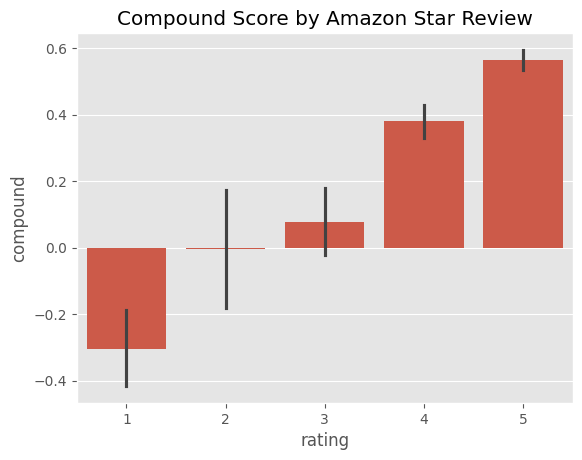

In [34]:
# Plotting VADER results

ax = sns.barplot(data=vaders, x = 'rating',y='compound')
ax.set_title('Compound Score by Amazon Star Review')
plt.show()

This bar graph displays the relationship between Amazon star ratings (from 1 to 5) and the compound sentiment scores generated from sentiment analysis, specifically with the `compound` score from VADER. Here’s an interpretation:

1. **Compound Score**:
   - The compound score is a single, overall sentiment score that ranges from -1 (most negative) to +1 (most positive).
   
2. **Rating and Compound Score Relationship**:
   - **1-star ratings** have a negative compound score, indicating that reviews with a 1-star rating generally express negative sentiment.
   - **2-star ratings** have a very low or slightly negative compound score, showing a slight improvement in sentiment compared to 1-star but still on the negative or neutral side.
   - **3-star ratings** have a compound score close to zero, suggesting that these reviews are generally neutral.
   - **4-star ratings** show a positive compound score, indicating positive sentiment, though not as high as the 5-star reviews.
   - **5-star ratings** have the highest compound score, reflecting strongly positive sentiment.

3. **Error Bars**:
   - Each bar has an error bar, indicating the variance or spread in compound scores within each rating group.
   - For lower ratings (1-2 stars), the error bars are larger, indicating more variability in sentiment for these ratings. This could mean that some reviews with low ratings may still carry mixed or even slightly positive sentiments, or the language used in lower ratings is less consistent.
   - For higher ratings (4-5 stars), the error bars are smaller, suggesting more consistent positive sentiment within these ratings.

### Overall Insights
- The graph confirms that there is a positive correlation between Amazon star ratings and sentiment scores: higher ratings tend to have more positive sentiment.
- This pattern aligns with expectations, where higher ratings generally reflect satisfaction, and lower ratings reflect dissatisfaction.

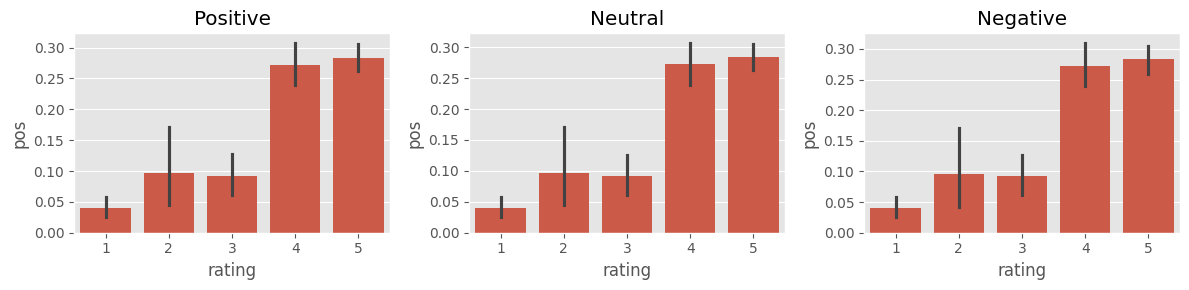

In [35]:
fig, axs = plt.subplots(1,3,figsize=(12,3))
sns.barplot(data=vaders, x='rating', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='rating', y='pos', ax=axs[1])
sns.barplot(data=vaders, x='rating', y='pos', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

## Performance Metrics

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert ratings to actual sentiment labels
def get_actual_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

# Convert compound score to predicted sentiment labels
def get_predicted_sentiment(compound):
    if compound >= 0.05:
        return "Positive"
    elif -0.05 < compound < 0.05:
        return "Neutral"
    else:
        return "Negative"

# Apply the functions to create actual and predicted sentiment columns
vaders['actual_sentiment'] = vaders['rating'].apply(get_actual_sentiment)
vaders['predicted_sentiment'] = vaders['compound'].apply(get_predicted_sentiment)

# Calculate metrics
accuracy = accuracy_score(vaders['actual_sentiment'], vaders['predicted_sentiment'])
precision = precision_score(vaders['actual_sentiment'], vaders['predicted_sentiment'], average='weighted')
recall = recall_score(vaders['actual_sentiment'], vaders['predicted_sentiment'], average='weighted')
f1 = f1_score(vaders['actual_sentiment'], vaders['predicted_sentiment'], average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Accuracy: 0.7629716981132075
Precision: 0.8335640621626426
Recall: 0.7629716981132075
F1 Score: 0.7916527291048179


Text(0.5, 1.0, 'Actual sentiments')

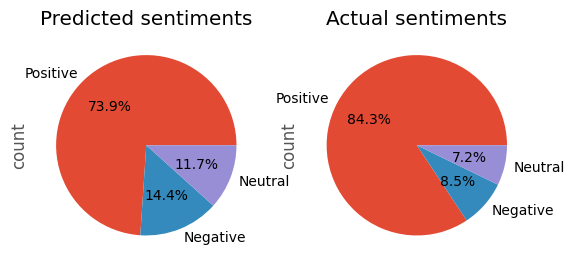

In [37]:
plt.subplot(1,2,1)
vaders['predicted_sentiment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Predicted sentiments')

plt.subplot(1,2,2)
vaders['actual_sentiment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Actual sentiments')


## There are some reviews that are being misclassified according to above graphs

## VADER MODEL

After preprocessing

In [38]:
# create preprocess_text function
def preprocess_text(text):

    # Tokenize the text

    tokens = nltk.word_tokenize(text.lower())




    # Remove stop words

    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]




    # Lemmatize the tokens

    lemmatizer = WordNetLemmatizer()

    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]




    # Join the tokens back into a string

    processed_text = ' '.join(lemmatized_tokens)

    return processed_text

# apply the function df


df['body'] = df['body'].apply(preprocess_text)
df

,product,title,rating,body,Model number
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Accurate bp monitor,5,'s accurate reliable affordable . great product .,7143T1
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"Good, but....",4,omron gold standard home bp measurement . good...,7143T1
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Precision and Convenience Combined,5,"recently purchased blood pressure meter mom , ...",7143T1
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Fullfilled my wish,5,searched found product amazon . good value mon...,7143T1
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Lots of features are missing.,3,"doubt quality , size cup short , accuracy good...",7143T1
...,...,...,...,...,...
846,Omron Smart Elite+ HEM 7600T Tubeless 360° Acc...,Excellent,5,excellent hassle free,7600T
847,Omron Smart Elite+ HEM 7600T Tubeless 360° Acc...,Very good quality Blood pressure monitor,5,"bought omron smart elite+ hem 7600t may 2019 ,...",7600T
848,Omron Smart Elite+ HEM 7600T Tubeless 360° Acc...,Easy to use ...as per quality ⭐⭐⭐⭐⭐,4,per rate litt ... bit costly,7600T
849,Omron Smart Elite+ HEM 7600T Tubeless 360° Acc...,Easy to use,5,good looking,7600T


In [39]:
# Running polarity score on entire dataset

res_p = {}
for i,row in tqdm(df.iterrows(), total=len(df)):
    text = row['body']
    myid = i
    res_p[myid] = sia.polarity_scores(text)

  0%|          | 0/848 [00:00<?, ?it/s]

In [40]:
vaders_p = pd.DataFrame(res_p).T
vaders_p.head()

,neg,neu,pos,compound
0,0.000,0.549,0.451,0.6249
1,0.000,0.700,0.300,0.9563
2,0.082,0.650,0.268,0.9590
3,0.000,0.533,0.467,0.7184
4,0.082,0.621,0.297,0.7650


In [41]:
# merging df with vaders so that reviews and their corresponding scores are together

vaders_p = pd.concat([df, vaders_p], axis=1)
vaders_p.head()

,product,title,rating,body,Model number,neg,neu,pos,compound
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Accurate bp monitor,5,'s accurate reliable affordable . great product .,7143T1,0.000,0.549,0.451,0.6249
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"Good, but....",4,omron gold standard home bp measurement . good...,7143T1,0.000,0.700,0.300,0.9563
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Precision and Convenience Combined,5,"recently purchased blood pressure meter mom , ...",7143T1,0.082,0.650,0.268,0.9590
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Fullfilled my wish,5,searched found product amazon . good value mon...,7143T1,0.000,0.533,0.467,0.7184
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Lots of features are missing.,3,"doubt quality , size cup short , accuracy good...",7143T1,0.082,0.621,0.297,0.7650


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert ratings to actual sentiment labels
def get_actual_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

# Convert compound score to predicted sentiment labels
def get_predicted_sentiment(compound):
    if compound >= 0.05:
        return "Positive"
    elif -0.05 < compound < 0.05:
        return "Neutral"
    else:
        return "Negative"

# Apply the functions to create actual and predicted sentiment columns
vaders_p['actual_sentiment'] = vaders_p['rating'].apply(get_actual_sentiment)
vaders_p['predicted_sentiment'] = vaders_p['compound'].apply(get_predicted_sentiment)

# Calculate metrics
accuracy_p = accuracy_score(vaders_p['actual_sentiment'], vaders_p['predicted_sentiment'])
precision_p = precision_score(vaders_p['actual_sentiment'], vaders_p['predicted_sentiment'], average='weighted')
recall_p = recall_score(vaders_p['actual_sentiment'], vaders_p['predicted_sentiment'], average='weighted')
f1_p = f1_score(vaders_p['actual_sentiment'], vaders_p['predicted_sentiment'], average='weighted')

print(f"Accuracy_p: {accuracy_p}")
print(f"Precision_p: {precision_p}")
print(f"Recall_p: {recall_p}")
print(f"F1 Score_p: {f1_p}")


Accuracy_p: 0.7783018867924528
Precision_p: 0.8148402403414196
Recall_p: 0.7783018867924528
F1 Score_p: 0.7950826632211635


## Comparing preprocessed vs notprocessed metrics

In [43]:
print(f"Accuracy_p: {accuracy_p}")
print(f"Precision_p: {precision_p}")
print(f"Recall_p: {recall_p}")
print(f"F1 Score_p: {f1_p}")

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Accuracy_p: 0.7783018867924528
Precision_p: 0.8148402403414196
Recall_p: 0.7783018867924528
F1 Score_p: 0.7950826632211635
Accuracy: 0.7629716981132075
Precision: 0.8335640621626426
Recall: 0.7629716981132075
F1 Score: 0.7916527291048179


Text(0.5, 1.0, 'Actual sentiments')

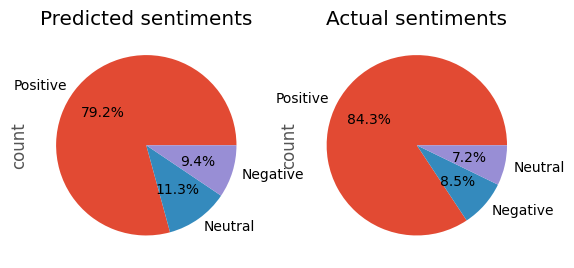

In [44]:
plt.subplot(1,2,1)
vaders_p['predicted_sentiment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Predicted sentiments')

plt.subplot(1,2,2)
vaders_p['actual_sentiment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Actual sentiments')

# it is seen that there are more positive reviews throughout

In [45]:
# Define the function to capture misclassification
def classification(row):
    actual_sentiment = row['actual_sentiment']
    predicted_sentiment = row['predicted_sentiment']
    if actual_sentiment == predicted_sentiment:
        return "Correct"
    else:
        return "Wrong"

# Apply the function to create the classification column
vaders['classification'] = vaders.apply(classification, axis=1)


<Axes: ylabel='count'>

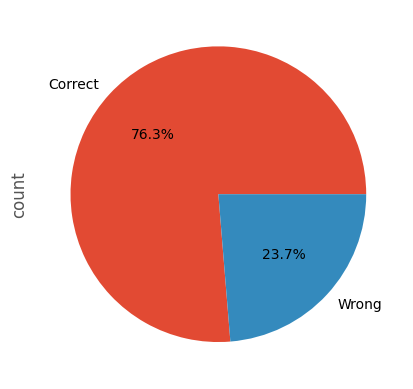

In [46]:
vaders['classification'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [47]:
vaders['classification'].value_counts()

classification
Correct    647
Wrong      201
Name: count, dtype: int64

In [48]:
vaders['classification']=='wrong'

0      False
1      False
2      False
3      False
4      False
       ...  
846    False
847    False
848    False
849    False
850    False
Name: classification, Length: 848, dtype: bool

In [49]:
# Display one 'body' where classification is 'Wrong'
wrong_classification = vaders[vaders['classification'] == "Wrong"]

if not wrong_classification.empty:
    print("Example of misclassified review body:")
    print(wrong_classification.iloc[8]['body'])
else:
    print("No misclassified reviews found.")


Example of misclassified review body:
Product comes with a AC adapter and it works on both batteries and on AC adapter. However if AC adapter is plugged in on to the divice and if it is not connected to the power the device doesnot turn on battery. The omron connect app works by taking a photo of the reading Insted of wireless connectivity.


## High frequency words

In [50]:
import re
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, pos_tag
from collections import Counter

# Load stop words
stop_words = set(stopwords.words('english'))

# Define a function to clean and tokenize the text
def preprocess_text(text):
    # Lowercase, remove punctuation, and tokenize
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    tokens = word_tokenize(text)
    # Remove stopwords and keep only nouns (common features are usually nouns)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word, pos in pos_tag(tokens) if pos.startswith('NN')]
    return tokens

# Apply preprocessing and collect all tokens from the 'body' column
all_tokens = []
for review in vaders['body']:
    all_tokens.extend(preprocess_text(review))

# Count the frequency of each word
word_counts = Counter(all_tokens)

# Display the most common words (top features mentioned)
top_features = word_counts.most_common(20)  # Adjust the number as needed
print("Most common features mentioned in reviews:")
for feature, count in top_features:
    print(f"{feature}: {count}")


Most common features mentioned in reviews:
product: 384
readings: 259
bp: 246
use: 233
monitor: 195
pressure: 194
blood: 181
machine: 180
device: 131
omron: 130
cuff: 103
accuracy: 102
app: 89
time: 88
reading: 81
quality: 74
accurate: 64
data: 61
health: 60
battery: 60


## Connotation of high frequency words

In [51]:
import re
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, pos_tag, sent_tokenize
from collections import Counter, defaultdict
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Load stop words and initialize VADER sentiment analyzer
stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()

# Define a function to clean and tokenize the text
def preprocess_text(text):
    # Lowercase, remove punctuation, and tokenize
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    tokens = word_tokenize(text)
    # Remove stopwords and keep only nouns (common features are usually nouns)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word, pos in pos_tag(tokens) if pos.startswith('NN')]
    return tokens

# Define a function to extract sentiment around feature words
def extract_feature_sentiment(text, features):
    feature_sentiments = defaultdict(list)  # Stores sentiment scores for each feature
    sentences = sent_tokenize(text.lower())  # Split text into sentences
    
    for sentence in sentences:
        # Check if any feature is mentioned in the sentence
        for feature in features:
            if feature in sentence:
                # Get the sentiment score of the sentence
                sentiment = sia.polarity_scores(sentence)
                # Append the compound score (overall sentiment) for this feature
                feature_sentiments[feature].append(sentiment['compound'])
                
    return feature_sentiments

# Define a list of known features
features = ['product','readings', 'use', 'monitor', 'machine', 'device', 'omron', 'cuff', 'accuracy', 'app', 'time', 'reading'
                'quality', 'accurate', 'data', 'health', 'battery']

# Apply the sentiment extraction on each review and aggregate the results
all_feature_sentiments = defaultdict(list)
for review in vaders['body']:
    feature_sentiments = extract_feature_sentiment(review, features)
    for feature, scores in feature_sentiments.items():
        all_feature_sentiments[feature].extend(scores)

# Summarize the sentiment for each feature
feature_summary = {feature: {'positive': sum(1 for s in scores if s > 0),
                             'negative': sum(1 for s in scores if s < 0),
                             'neutral': sum(1 for s in scores if s == 0)}
                   for feature, scores in all_feature_sentiments.items()}

# Print the summary
print("Feature Sentiment Summary:")
for feature, sentiments in feature_summary.items():
    print(f"{feature.capitalize()}: Positive = {sentiments['positive']}, "
          f"Negative = {sentiments['negative']}, Neutral = {sentiments['neutral']}")


Feature Sentiment Summary:
Accurate: Positive = 130, Negative = 23, Neutral = 90
Product: Positive = 277, Negative = 38, Neutral = 67
Omron: Positive = 153, Negative = 41, Neutral = 50
Time: Positive = 59, Negative = 30, Neutral = 47
App: Positive = 174, Negative = 30, Neutral = 62
Cuff: Positive = 83, Negative = 21, Neutral = 19
Health: Positive = 51, Negative = 9, Neutral = 10
Readings: Positive = 124, Negative = 39, Neutral = 104
Use: Positive = 333, Negative = 67, Neutral = 85
Monitor: Positive = 164, Negative = 64, Neutral = 45
Accuracy: Positive = 75, Negative = 19, Neutral = 29
Machine: Positive = 100, Negative = 35, Neutral = 40
Battery: Positive = 31, Negative = 12, Neutral = 16
Device: Positive = 92, Negative = 22, Neutral = 37
Data: Positive = 34, Negative = 7, Neutral = 19


This list represents the **most frequently mentioned features** in the reviews. Each feature's count shows how often it was directly referenced in the review body. Here’s what this implies for understanding the customer feedback:

1. **Highly Mentioned Features**: The top features (e.g., "product," "readings," "bp," "use," and "monitor") have high counts, indicating they are critical aspects of the customer experience. These are likely fundamental to the device's function (e.g., "readings," "use," and "monitor") or refer to the product and brand itself.

2. **Primary Device Functions**:
   - **Readings** and **Reading**: Combined, "readings" (259) and "reading" (81) are mentioned frequently, suggesting that the accuracy, reliability, or frequency of blood pressure readings is a significant focus in the reviews.
   - **BP** (246) and **Pressure** (194): These counts reinforce that blood pressure measurement—the primary function of the device—is central to customer interest.
   - **Blood** (181): "Blood" in combination with “pressure” likely reflects phrases like "blood pressure" rather than stand-alone mentions, confirming that accurate blood pressure monitoring is a core feature for users.
  
3. **Usability**:
   - **Use** (233) and **Machine** (180): High mentions of "use" indicate that usability is a significant concern or point of interest, as well as terms like "machine" and "device." This suggests that customers focus on how easy it is to operate and handle the device.
   - **Monitor** (195): The device’s primary function as a monitor is another core focus, reflecting expectations for accuracy and ease in measurement display.

4. **Additional Features and Qualities**:
   - **Cuff** (103): This is often critical in BP monitors, as customers may discuss cuff size, comfort, and fitting—factors that contribute significantly to their overall experience.
   - **App** (89): Mentions of the app highlight the popularity or relevance of digital features, possibly referring to Bluetooth connectivity or data tracking capabilities.
   - **Battery** (60): While not as frequently mentioned as some other features, battery performance is still a noted aspect, possibly referring to its lifespan, charging, or the power needed for operation.

5. **Performance and Quality**:
   - **Accuracy** (102) and **Accurate** (64): These mentions underline how vital accuracy is in a medical device, as customers depend on its reliability for health monitoring.
   - **Quality** (74): The quality references may include durability, build quality, and perceived value, which are important for customer satisfaction and long-term usage.
   - **Data** (61): This could relate to data recording, tracking, or the ability to analyze past readings, particularly useful for customers looking to monitor health trends.

6. **Brand and Health**:
   - **Omron** (130): The brand name's frequent mention indicates strong brand recognition, and may also reflect consumer perceptions of brand quality and reliability.
   - **Health** (60): Indicates that customers view the device within the broader context of managing their health, not just monitoring individual readings.

This frequency analysis helps identify features that matter most to customers, allowing for targeted improvements. For instance, ensuring high accuracy and reliability in **readings** and **monitor** functions or improving **app** functionality could increase customer satisfaction. Additionally, understanding how these features correlate with positive or negative sentiment could further guide product and marketing strategies.

## Roberta Model

In [52]:
import numpy as np

In [53]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [54]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

#loading a model on twitter dataset
#using trained weights of the above model and applying to our dataset.

In [55]:
#VADER RESULTS

print(example)
sia.polarity_scores(example)

I have bought this bp monitor 4 months before still now it works fine. The adaptor mode usage is very useful, Even it doesn't consume much power in battery mode as well. Nice product 👍


{'neg': 0.0, 'neu': 0.739, 'pos': 0.261, 'compound': 0.8357}

In [56]:
#Run for ROBERTA model

encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text) #running pretrained model
scores = output[0][0].detach().numpy() #convert tensor to numpy to store locally
scores = softmax(scores) ##what is softmax?????

In [57]:
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': 0.0021967757, 'roberta_neu': 0.016341135, 'roberta_pos': 0.9814621}


In [58]:
#running Roberta on the whole dataset

def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [59]:
#combining vader and roberta results

res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['body']
        myid = i
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/848 [00:00<?, ?it/s]

Broke for id 516


In [60]:
res

{0: {'vader_neg': 0.0,
  'vader_neu': 0.549,
  'vader_pos': 0.451,
  'vader_compound': 0.6249,
  'roberta_neg': 0.0038794228,
  'roberta_neu': 0.052501053,
  'roberta_pos': 0.94361955},
 1: {'vader_neg': 0.0,
  'vader_neu': 0.7,
  'vader_pos': 0.3,
  'vader_compound': 0.9563,
  'roberta_neg': 0.077609144,
  'roberta_neu': 0.44935793,
  'roberta_pos': 0.4730329},
 2: {'vader_neg': 0.082,
  'vader_neu': 0.65,
  'vader_pos': 0.268,
  'vader_compound': 0.959,
  'roberta_neg': 0.005300038,
  'roberta_neu': 0.14186865,
  'roberta_pos': 0.8528313},
 3: {'vader_neg': 0.0,
  'vader_neu': 0.533,
  'vader_pos': 0.467,
  'vader_compound': 0.7184,
  'roberta_neg': 0.0073572714,
  'roberta_neu': 0.13231656,
  'roberta_pos': 0.8603262},
 4: {'vader_neg': 0.082,
  'vader_neu': 0.621,
  'vader_pos': 0.297,
  'vader_compound': 0.765,
  'roberta_neg': 0.02092898,
  'roberta_neu': 0.19663423,
  'roberta_pos': 0.7824368},
 5: {'vader_neg': 0.0,
  'vader_neu': 0.282,
  'vader_pos': 0.718,
  'vader_compound'

In [61]:
# Convert the `res` dictionary to a DataFrame
res_df = pd.DataFrame.from_dict(res, orient='index')

# Merge the sentiment DataFrame with the original DataFrame on the index
results_df = df.merge(res_df, left_index=True, right_index=True)

# Display the merged DataFrame
results_df.head()


,product,title,rating,body,Model number,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Accurate bp monitor,5,'s accurate reliable affordable . great product .,7143T1,0.000,0.549,0.451,0.6249,0.003879,0.052501,0.943620
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"Good, but....",4,omron gold standard home bp measurement . good...,7143T1,0.000,0.700,0.300,0.9563,0.077609,0.449358,0.473033
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Precision and Convenience Combined,5,"recently purchased blood pressure meter mom , ...",7143T1,0.082,0.650,0.268,0.9590,0.005300,0.141869,0.852831
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Fullfilled my wish,5,searched found product amazon . good value mon...,7143T1,0.000,0.533,0.467,0.7184,0.007357,0.132317,0.860326
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Lots of features are missing.,3,"doubt quality , size cup short , accuracy good...",7143T1,0.082,0.621,0.297,0.7650,0.020929,0.196634,0.782437


In [62]:
#Use lambda function to label tweet as positive, negative or neutral
results_df['Roberta_Analysis'] = results_df.apply(lambda x:'Negative' if x['roberta_neg'] >
                     x['roberta_neu'] and x['roberta_neu']
                     > x['roberta_pos'] else ('Neutral' if x['roberta_neu']>x['roberta_pos'] else 'Positive'),axis=1)
results_df['Roberta_Analysis'].head()

0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: Roberta_Analysis, dtype: object

In [63]:
results_df.head(10)

,product,title,rating,body,Model number,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,Roberta_Analysis
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Accurate bp monitor,5,'s accurate reliable affordable . great product .,7143T1,0.000,0.549,0.451,0.6249,0.003879,0.052501,0.943620,Positive
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"Good, but....",4,omron gold standard home bp measurement . good...,7143T1,0.000,0.700,0.300,0.9563,0.077609,0.449358,0.473033,Positive
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Precision and Convenience Combined,5,"recently purchased blood pressure meter mom , ...",7143T1,0.082,0.650,0.268,0.9590,0.005300,0.141869,0.852831,Positive
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Fullfilled my wish,5,searched found product amazon . good value mon...,7143T1,0.000,0.533,0.467,0.7184,0.007357,0.132317,0.860326,Positive
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Lots of features are missing.,3,"doubt quality , size cup short , accuracy good...",7143T1,0.082,0.621,0.297,0.7650,0.020929,0.196634,0.782437,Positive
5,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Very useful,4,"great product , easy use . reliable user frien...",7143T1,0.000,0.282,0.718,0.8807,0.002823,0.037188,0.959989,Positive
6,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Very good,5,work well expected,7143T1,0.000,0.488,0.512,0.2732,0.016370,0.372511,0.611119,Positive
7,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Very good product,5,sateek maap,7143T1,0.000,1.000,0.000,0.0000,0.219507,0.587235,0.193258,Neutral
8,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Omran bp machine,4,good use,7143T1,0.000,0.256,0.744,0.4404,0.051776,0.325374,0.622850,Positive
9,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Okay,4,medium could loaded . product okay wireless bl...,7143T1,0.000,0.685,0.315,0.5574,0.009706,0.549581,0.440713,Neutral


In [64]:
# Convert ratings to actual sentiment labels
def get_actual_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

# Convert compound score to predicted sentiment labels
def get_predicted_sentiment(compound):
    if compound >= 0.05:
        return "Positive"
    elif -0.05 < compound < 0.05:
        return "Neutral"
    else:
        return "Negative"

# Apply the functions to create actual and predicted sentiment columns
results_df['Vader_Analysis'] = results_df['vader_compound'].apply(get_predicted_sentiment)
results_df['actual_sentiment'] = results_df['rating'].apply(get_actual_sentiment)


In [65]:
results_df.head(10)

,product,title,rating,body,Model number,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,Roberta_Analysis,Vader_Analysis,actual_sentiment
0,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Accurate bp monitor,5,'s accurate reliable affordable . great product .,7143T1,0.000,0.549,0.451,0.6249,0.003879,0.052501,0.943620,Positive,Positive,Positive
1,Omron HEM 7143T1 Digital Bluetooth Blood Press...,"Good, but....",4,omron gold standard home bp measurement . good...,7143T1,0.000,0.700,0.300,0.9563,0.077609,0.449358,0.473033,Positive,Positive,Positive
2,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Precision and Convenience Combined,5,"recently purchased blood pressure meter mom , ...",7143T1,0.082,0.650,0.268,0.9590,0.005300,0.141869,0.852831,Positive,Positive,Positive
3,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Fullfilled my wish,5,searched found product amazon . good value mon...,7143T1,0.000,0.533,0.467,0.7184,0.007357,0.132317,0.860326,Positive,Positive,Positive
4,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Lots of features are missing.,3,"doubt quality , size cup short , accuracy good...",7143T1,0.082,0.621,0.297,0.7650,0.020929,0.196634,0.782437,Positive,Positive,Neutral
5,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Very useful,4,"great product , easy use . reliable user frien...",7143T1,0.000,0.282,0.718,0.8807,0.002823,0.037188,0.959989,Positive,Positive,Positive
6,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Very good,5,work well expected,7143T1,0.000,0.488,0.512,0.2732,0.016370,0.372511,0.611119,Positive,Positive,Positive
7,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Very good product,5,sateek maap,7143T1,0.000,1.000,0.000,0.0000,0.219507,0.587235,0.193258,Neutral,Neutral,Positive
8,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Omran bp machine,4,good use,7143T1,0.000,0.256,0.744,0.4404,0.051776,0.325374,0.622850,Positive,Positive,Positive
9,Omron HEM 7143T1 Digital Bluetooth Blood Press...,Okay,4,medium could loaded . product okay wireless bl...,7143T1,0.000,0.685,0.315,0.5574,0.009706,0.549581,0.440713,Neutral,Positive,Positive


In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_score_vaders = accuracy_score(results_df['actual_sentiment'],results_df['Vader_Analysis'])
precision_score_vaders = precision_score(results_df['actual_sentiment'],results_df['Vader_Analysis'], average='weighted')
recall_score_vaders = recall_score(results_df['actual_sentiment'],results_df['Vader_Analysis'], average='weighted')
f1_score_vaders = f1_score(results_df['actual_sentiment'],results_df['Vader_Analysis'], average='weighted')

accuracy_score_roberta = accuracy_score(results_df['actual_sentiment'],results_df['Roberta_Analysis'])
precision_score_roberta = precision_score(results_df['actual_sentiment'],results_df['Roberta_Analysis'], average='weighted')
recall_score_roberta = recall_score(results_df['actual_sentiment'],results_df['Roberta_Analysis'], average='weighted')
f1_score_roberta = f1_score(results_df['actual_sentiment'],results_df['Roberta_Analysis'], average='weighted') # average='weighted' because 3 classes involved

In [67]:
print('VADER RESULTS')
print(f"Accuracy_p: {accuracy_score_vaders}")
print(f"Precision_p: {precision_score_vaders}")
print(f"Recall_p: {recall_score_vaders}")
print(f"F1 Score_p: {f1_score_vaders}")

print('ROBERTA RESULTS')
print(f"Accuracy_p: {accuracy_score_roberta}")
print(f"Precision_p: {precision_score_roberta}")
print(f"Recall_p: {recall_score_roberta}")
print(f"F1 Score_p: {f1_score_roberta}")

VADER RESULTS
Accuracy_p: 0.7792207792207793
Precision_p: 0.8154405716179469
Recall_p: 0.7792207792207793
F1 Score_p: 0.79584033202674
ROBERTA RESULTS
Accuracy_p: 0.6953955135773318
Precision_p: 0.8690244672133592
Recall_p: 0.6953955135773318
F1 Score_p: 0.7585501464567237


Text(0.5, 1.0, 'Vader sentiments')

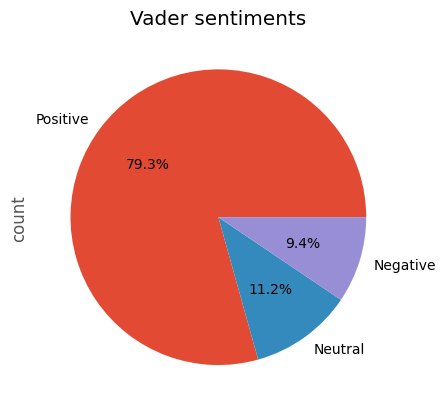

In [68]:
results_df['Vader_Analysis'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Vader sentiments')

Text(0.5, 1.0, 'Actual sentiments')

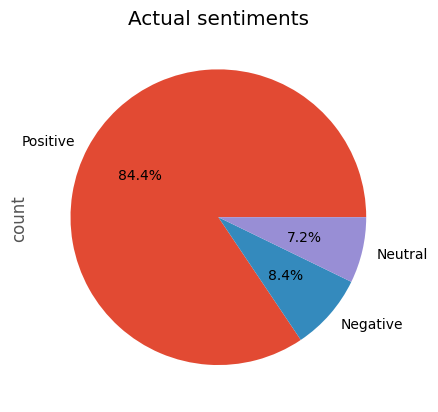

In [69]:
results_df['actual_sentiment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Actual sentiments')

This is a confusion matrix for a sentiment classification model, showing how well the model predicted sentiment categories (Negative, Neutral, and Positive) compared to the true sentiment labels. Here’s a breakdown of each section:

- **True Negative (Negative sentiment correctly predicted as Negative)**: 33 reviews.
- **False Negative (Negative sentiment misclassified as Neutral or Positive)**: 
  - Predicted as Neutral: 33 reviews.
  - Predicted as Positive: 5 reviews.

- **True Neutral (Neutral sentiment correctly predicted as Neutral)**: 35 reviews.
- **False Neutral (Neutral sentiment misclassified as Negative or Positive)**: 
  - Predicted as Negative: 15 reviews.
  - Predicted as Positive: 11 reviews.

- **True Positive (Positive sentiment correctly predicted as Positive)**: 521 reviews.
- **False Positive (Positive sentiment misclassified as Negative or Neutral)**: 
  - Predicted as Negative: 22 reviews.
  - Predicted as Neutral: 172 reviews.

### Insights:
- The model performs well in predicting Positive sentiments, with most Positive reviews correctly classified (521).
- There is a noticeable number of Positive reviews misclassified as Neutral (172), which might indicate that the model struggles to differentiate between Positive and Neutral.
- The model has lower performance in predicting Negative and Neutral sentiments, with significant misclassifications in these categories.

Improvement in distinguishing between Neutral and other sentiments could potentially enhance the model’s accuracy, especially in reducing misclassifications in the Positive and Neutral categories.

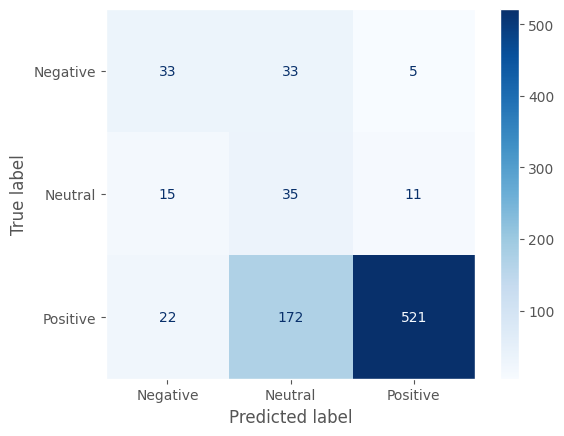

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(results_df['actual_sentiment'], results_df['Roberta_Analysis']), display_labels=np.unique(results_df['actual_sentiment']))
disp.plot(cmap='Blues') 
plt.grid(False)

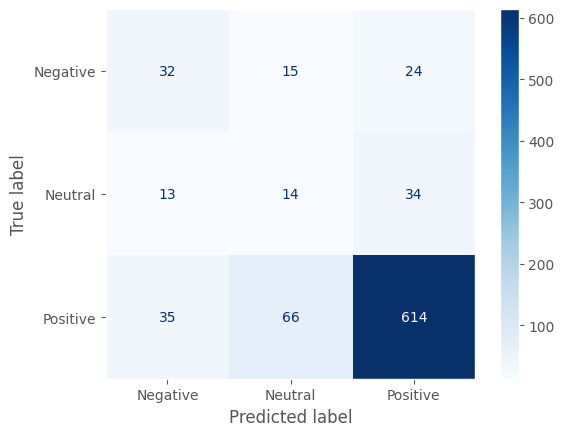

In [76]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(results_df['actual_sentiment'], results_df['Vader_Analysis']), display_labels=np.unique(results_df['actual_sentiment']))
disp.plot(cmap='Blues') 
plt.grid(False)